# Pre-processando o banco de dados neo4j para alimentar algorítmo `node2vec` da stellargraph

In [1]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg
import nltk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

driver = GraphDatabase.driver( os.getenv('N4J_URL'),  auth=basic_auth(os.getenv('N4J_USER'), os.getenv('N4J_PASS')))

# Creating StellarGraph

### Puxando Edges

In [3]:
print('Preparando Dataset')
pulling_query = """\
            MATCH (a)-->(b)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

Preparando Dataset
(13591, 2)


,source,target
0,2273,9252
1,2273,9249
2,2273,9248
3,2273,9247
4,2273,9246


### puxando labels

In [64]:
pulling_query = """\
                MATCH (a)-[*1]-(b:AREA)
                RETURN ID(a) AS source, b.name AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
#labels.drop_duplicates(subset='source', keep='first')

print(label_db.shape)
duplicated = label_db['source'].duplicated()
print(duplicated.value_counts())
duplicated_index = duplicated[duplicated == True].index
print(duplicated_index)
label_db = label_db[label_db['source'].duplicated()]
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
print(label_db.shape)
labels.head()

(3491, 2)
False    2882
True      609
Name: source, dtype: int64
Int64Index([1481, 1482, 1485, 1486, 1498, 1515, 1517, 1518, 1519, 1520,
            ...
            3426, 3427, 3429, 3430, 3431, 3432, 3447, 3473, 3486, 3490],
           dtype='int64', length=609)
(609, 2)


6289    Society
6285    Society
6296    Society
6297    Society
7603    Society
dtype: object

In [12]:

# no_label_db = pd.DataFrame([dict(row) for row in result])
# no_labels = pd.Series(data =no_label_db['subject'].values, index = no_label_db['source'].values)
# print(no_labels.shape)
# no_labels.head()

CypherSyntaxError: Invalid input ':': expected whitespace, a variable, RelationshipsPattern, an expression or ']' (line 2, column 35 (offset: 56))
"            WHERE NOT EXISTS (a)-[:BELONGS_TO]-(b:AREA)"
                                               ^

### Criando grafo

In [30]:
print('Criando Grafo')
graph = sg.StellarGraph(edges =  edges_db)
print(graph.info())

Criando Grafo
StellarGraph: Undirected multigraph
 Nodes: 3132, Edges: 13591

 Node types:
  default: [3132]
    Features: none
    Edge types: default-default->default

 Edge types:
    default-default->default: [13591]
        Weights: all 1 (default)
        Features: none


### Criando Random Walks e alimentando o algoritmo com strings dessas walks

In [32]:
import time

start = time.time()
print('RANDOM WALKS')
walk_length = 20  # maximum/ length of a random walk to use throughout this noteboo

rw = sg.data.BiasedRandomWalk(graph)
weighted_walks = rw.run(
    nodes=graph.nodes(),  # root nodes
    length=walk_length,  # maximum length of a random walk
    n=10,  # number of random walks per root node
    p=0.5,  # Defines (unormalised) probability, 1/p, of returning to source node
    q=0.5,  # Defines (unormalised) probability, 1/q, for moving away from source node
    weighted=True,  # for weighted random walks
    seed=42,  # random seed fixed for reproducibility
)
print("Number of random walks: {}".format(len(weighted_walks)))

string_walks = [[str(n) for n in walk] for walk in weighted_walks]
end = time.time()
print('TEMPO PARA GERAR RWs',end - start)

RANDOM WALKS
Number of random walks: 31320
TEMPO PARA GERAR RWs 43.96907639503479


In [33]:
print('Treino')
from gensim.models import Word2Vec
weighted_model = Word2Vec(
    string_walks, size=128, window=5, min_count=0, sg=1, workers=1, iter=1
)

Treino


### Embeddings

In [34]:
print('Plot')
# Retrieve node embeddings and corresponding subjects
node_ids = weighted_model.wv.index2word  # list of node IDs
weighted_node_embeddings = (
    weighted_model.wv.vectors
)  # numpy.ndarray of size number of nodes times embeddings dimensionality
# the gensim ordering may not match the StellarGraph one, so rearrange
int_ids = [int(node) for node in node_ids]



Plot


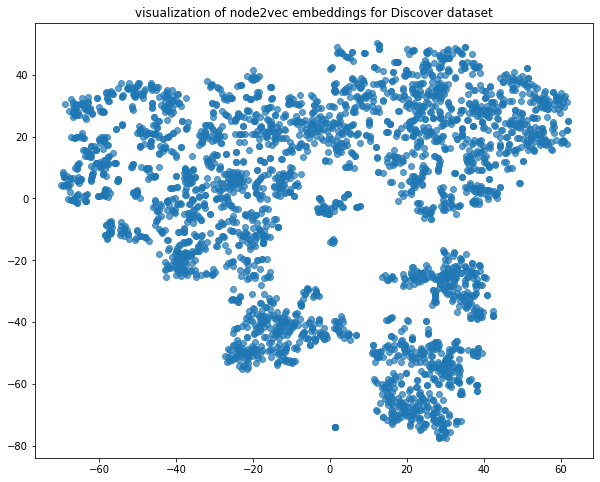

In [36]:
#node_targets = labels.loc[int_ids].astype("category")
tsne = TSNE(n_components=2, random_state=42)
weighted_node_embeddings_2d = tsne.fit_transform(weighted_node_embeddings)

# draw the points
alpha = 0.7

plt.figure(figsize=(10, 8))
plt.scatter(
    weighted_node_embeddings_2d[:, 0],
    weighted_node_embeddings_2d[:, 1],
    #c=node_targets.cat.codes,
    cmap="jet",
    alpha=0.7,
)
plt.title(
    "visualization of node2vec embeddings for Discover dataset")
plt.show()

### Adicionando ao neo4j

In [11]:
print('Adicionando embeddings')
pulling_query = """\
            MATCH (a)
            WHERE  ID(a) = $id
            SET a.embedding = $emb
            """
with driver.session() as sess:
    for node in int_ids:
        emb = map(float,list(weighted_model.wv[str(node)]))
        sess.run(pulling_query,{"id":node,"emb":emb})

Adicionando embeddings


### Retornando recomendações via python

In [15]:

final_query = """
MATCH (a:Blog),(b:Blog)
WHERE ID(a) = 6331 AND ID(a) <> ID(b) AND EXISTS (b.embedding)
RETURN DISTINCT a.title AS CLICK,a.label as FONTE, b.title AS RECOMENDACAO, b.label AS AREA, apoc.algo.cosineSimilarity(a.embedding,b.embedding) AS SIMILARIDADE ORDER BY SIMILARIDADE DESC LIMIT 15
"""
with driver.session() as sess:
    result = sess.run(final_query)
    df_final = pd.DataFrame([dict(row) for row in result])
print("----POSSÍVEIS LINKS----")
print(df_final)

----POSSÍVEIS LINKS----
                       CLICK FONTE  \
0   GraphQL in Plain English  None   
1   GraphQL in Plain English  None   
2   GraphQL in Plain English  None   
3   GraphQL in Plain English  None   
4   GraphQL in Plain English  None   
5   GraphQL in Plain English  None   
6   GraphQL in Plain English  None   
7   GraphQL in Plain English  None   
8   GraphQL in Plain English  None   
9   GraphQL in Plain English  None   
10  GraphQL in Plain English  None   
11  GraphQL in Plain English  None   
12  GraphQL in Plain English  None   
13  GraphQL in Plain English  None   
14  GraphQL in Plain English  None   

                                         RECOMENDACAO  AREA  SIMILARIDADE  
0   Scanning Barcode or QR Code in an Angular App ...  None      0.767424  
1   Do not resolve your GraphQL fields like a REST...  None      0.718439  
2     Make REST APIs using AWS Lambda and API Gateway  None      0.716278  
3   How to Paginate Results with Shopify’s GraphQL...  None    